In [1]:
import pandas as pd
from load import load_dataset

dataset = load_dataset("futbol_uruguayo.csv")

#print(dataset.head())


In [2]:
#separamos cronologicamente el conjunto de entrenamiento y el de evaluacion
#la evaluacion se mantiene separada hasta haber elegido los hiperparametros

train = dataset[
    dataset["date"] < pd.Timestamp("2024-01-01")
].copy()

test = dataset[
    (dataset["date"] >= pd.Timestamp("2024-01-01"))
    & (dataset["date"] < pd.Timestamp("2026-01-01"))
].copy()

print("Cantidad de partidos de entrenamiento:", len(train))
print("Cantidad de partidos de evaluacion:", len(test))

Cantidad de partidos de entrenamiento: 14734
Cantidad de partidos de evaluacion: 472


In [3]:
import sys
import os

from pipeline import create_model_pipeline, pipeline_input_attributes


# Agrega la carpeta padre (Tarea1) al path de búsqueda de Python
sys.path.append(os.path.abspath(".."))


#hacemos el arbol de decision usando solamente el conjunto de entrenamiento
from naiveBayes.bayes import M_Estimator as BayesClassifier

bayes= BayesClassifier(m=1.0)

model = create_model_pipeline(bayes)

In [4]:
X_train = train[pipeline_input_attributes].copy()
y_train = train["result"].copy()

X_test = test[pipeline_input_attributes].copy()
y_test = test["result"].copy()

print("Filas de entrenamiento:", len(X_train))
print("Filas reservadas para evaluacion final:", len(X_test))

Filas de entrenamiento: 14734
Filas reservadas para evaluacion final: 472


In [5]:
import numpy as np

#cada temporada se valida usando solamente las temporadas anteriores
# Validamos usando todo el historial moderno (desde 2013)
validation_years = list(range(1950, 2023))
train_years = train["date"].dt.year.to_numpy()
window_years = 5 # Agregamos la ventana de tiempo
temporal_splits = []

for validation_year in validation_years:
    fit_indices = np.flatnonzero(
        (train_years < validation_year) & (train_years >= validation_year - window_years)
    )
    validation_indices = np.flatnonzero(
        train_years == validation_year
    )

    temporal_splits.append((
        fit_indices,
        validation_indices
    ))

    print(
        f"Validacion {validation_year}:",
        f"entrenamiento={len(fit_indices)},",
        f"validacion={len(validation_indices)}"
    )

Validacion 1950: entrenamiento=412, validacion=93
Validacion 1951: entrenamiento=415, validacion=90
Validacion 1952: entrenamiento=415, validacion=91
Validacion 1953: entrenamiento=414, validacion=90
Validacion 1954: entrenamiento=454, validacion=90
Validacion 1955: entrenamiento=454, validacion=90
Validacion 1956: entrenamiento=451, validacion=90
Validacion 1957: entrenamiento=451, validacion=90
Validacion 1958: entrenamiento=450, validacion=90
Validacion 1959: entrenamiento=450, validacion=91
Validacion 1960: entrenamiento=451, validacion=91
Validacion 1961: entrenamiento=452, validacion=92
Validacion 1962: entrenamiento=454, validacion=90
Validacion 1963: entrenamiento=454, validacion=132
Validacion 1964: entrenamiento=496, validacion=90
Validacion 1965: entrenamiento=495, validacion=90
Validacion 1966: entrenamiento=494, validacion=90
Validacion 1967: entrenamiento=492, validacion=90
Validacion 1968: entrenamiento=492, validacion=90
Validacion 1969: entrenamiento=450, validacion=12

In [6]:
from sklearn.model_selection import RandomizedSearchCV

# Busqueda local alrededor de los ganadores de la busqueda previa.
param_grid = {
    'preprocessing__draw_rate__discretizer__low_threshold': [
        0.25, 0.28, 0.3, 0.32, 0.35
    ],
    'preprocessing__draw_rate__discretizer__high_threshold': [
        0.5, 0.53, 0.55, 0.58, 0.6
    ],
    'preprocessing__differences__discretizer__record_margin': [
        0.05, 0.06, 0.075, 0.08, 0.1
    ],
    'preprocessing__differences__discretizer__last_matches_margin': [
        0.02, 0.03, 0.04, 0.05, 0.06
    ],
    'preprocessing__differences__discretizer__goal_difference_margin': [
        0.15, 0.18, 0.2, 0.22, 0.25
    ],
    'preprocessing__differences__discretizer__defense_margin': [
        0.2, 0.22, 0.25, 0.28, 0.3
    ],
    'preprocessing__differences__discretizer__attack_margin': [
        0.0, 0.02, 0.05, 0.1
    ],
    'preprocessing__differences__discretizer__elo_margin': [
        25.0, 50.0, 75.0, 100.0, 150.0
    ],
    'model__m': [
        0.0, 0.5, 1.0, 2.0, 5.0
    ],
    'model__fit_prior': [
        False, True
    ]
}

selection_metric = 'f1_macro'

scoring = {
    'accuracy': 'accuracy',
    'balanced_accuracy': 'balanced_accuracy',
    'f1_macro': 'f1_macro',
}

import random
from math import prod

n_iter = 500
random_state = 42
rng = random.Random(random_state)
parameter_names_search = sorted(param_grid)
candidate_count = min(n_iter, prod(len(values) for values in param_grid.values()))

# Incluimos la configuracion ganadora del grid search previo como baseline
baseline_values = (
    False,  # model__fit_prior
    0.0,    # model__m
    0.0,    # preprocessing__differences__discretizer__attack_margin
    0.25,   # preprocessing__differences__discretizer__defense_margin
    50.0,   # preprocessing__differences__discretizer__elo_margin
    0.2,    # preprocessing__differences__discretizer__goal_difference_margin
    0.04,   # preprocessing__differences__discretizer__last_matches_margin
    0.075,  # preprocessing__differences__discretizer__record_margin
    0.55,   # preprocessing__draw_rate__discretizer__high_threshold
    0.3,    # preprocessing__draw_rate__discretizer__low_threshold
)
sampled_parameters = [{name: [value] for name, value in zip(parameter_names_search, baseline_values)}]
seen_parameters = {baseline_values}

while len(sampled_parameters) < candidate_count:
    values = tuple(rng.choice(param_grid[name]) for name in parameter_names_search)
    if values not in seen_parameters:
        seen_parameters.add(values)
        sampled_parameters.append({
            name: [value] for name, value in zip(parameter_names_search, values)
        })

random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=sampled_parameters,
    n_iter=candidate_count,
    scoring=scoring,
    cv=temporal_splits, # 73 divisiones temporales
    n_jobs=-1,
    refit=selection_metric,
    random_state=random_state,
    verbose=1,
)

random_search.fit(X_train, y_train)

print('Hiperparametros seleccionados por F1 macro medio anual:')
print(random_search.best_params_)
print(f'F1 macro medio anual del ganador: {random_search.best_score_:.3%}')
best_acc = random_search.cv_results_['mean_test_accuracy'][random_search.best_index_]
print(f'Accuracy media anual del mismo ganador: {best_acc:.3%}')
best_balanced_acc = random_search.cv_results_['mean_test_balanced_accuracy'][random_search.best_index_]
print(f'Balanced accuracy media anual del mismo ganador: {best_balanced_acc:.3%}')


Fitting 73 folds for each of 500 candidates, totalling 36500 fits
Hiperparametros seleccionados por F1 macro medio anual:
{'preprocessing__draw_rate__discretizer__low_threshold': 0.32, 'preprocessing__draw_rate__discretizer__high_threshold': 0.53, 'preprocessing__differences__discretizer__record_margin': 0.08, 'preprocessing__differences__discretizer__last_matches_margin': 0.03, 'preprocessing__differences__discretizer__goal_difference_margin': 0.22, 'preprocessing__differences__discretizer__elo_margin': 75.0, 'preprocessing__differences__discretizer__defense_margin': 0.28, 'preprocessing__differences__discretizer__attack_margin': 0.0, 'model__m': 0.5, 'model__fit_prior': False}
F1 macro medio anual del ganador: 43.645%
Accuracy media anual del mismo ganador: 48.126%
Balanced accuracy media anual del mismo ganador: 45.673%


In [7]:
from IPython.display import display

results = pd.DataFrame(random_search.cv_results_)

parameter_columns = [column for column in results.columns if column.startswith("param_")]
# Primero mostramos el criterio de seleccion; las otras metricas lo complementan.
metric_names = [random_search.refit] + [metric for metric in scoring if metric != random_search.refit]
summary_columns = [
    f"{stat}_test_{metric}"
    for metric in metric_names
    for stat in ("mean", "std", "rank")
]
split_columns = [
    f"split{i}_test_{metric}"
    for metric in metric_names
    for i in range(len(validation_years))
]

results = results[parameter_columns + summary_columns + split_columns].sort_values(
    f"rank_test_{random_search.refit}", kind="stable"
)
rename_dict = {
    f"split{i}_test_{metric}": f"{metric}_{year}"
    for metric in metric_names
    for i, year in enumerate(validation_years)
}
results = results.rename(columns=rename_dict)

print("Primeros 10 candidatos, ordenados por F1 macro medio anual (mayor es mejor):")
display(results[summary_columns + parameter_columns].head(10))
# results conserva tambien las metricas de cada ano para inspeccionarlas.


Primeros 10 candidatos, ordenados por F1 macro medio anual (mayor es mejor):


,mean_test_f1_macro,std_test_f1_macro,rank_test_f1_macro,mean_test_accuracy,std_test_accuracy,rank_test_accuracy,mean_test_balanced_accuracy,std_test_balanced_accuracy,rank_test_balanced_accuracy,param_preprocessing__draw_rate__discretizer__low_threshold,param_preprocessing__draw_rate__discretizer__high_threshold,param_preprocessing__differences__discretizer__record_margin,param_preprocessing__differences__discretizer__last_matches_margin,param_preprocessing__differences__discretizer__goal_difference_margin,param_preprocessing__differences__discretizer__elo_margin,param_preprocessing__differences__discretizer__defense_margin,param_preprocessing__differences__discretizer__attack_margin,param_model__m,param_model__fit_prior
207,0.436447,0.061315,1,0.481257,0.061295,263,0.456735,0.059378,6,0.32,0.53,0.080,0.03,0.22,75.0,0.28,0.00,0.5,False
306,0.436052,0.059269,2,0.480517,0.059824,279,0.455419,0.057157,25,0.28,0.53,0.080,0.03,0.20,75.0,0.25,0.00,0.0,False
338,0.436039,0.058584,3,0.478393,0.059508,352,0.453935,0.058340,72,0.30,0.53,0.080,0.05,0.15,100.0,0.28,0.10,0.5,False
330,0.435893,0.058923,4,0.478515,0.057924,346,0.453904,0.057043,73,0.28,0.55,0.080,0.04,0.20,100.0,0.25,0.05,1.0,False
293,0.435749,0.061691,5,0.480057,0.061455,295,0.455319,0.060058,28,0.28,0.50,0.080,0.02,0.20,75.0,0.28,0.00,1.0,False
210,0.435674,0.060022,6,0.481095,0.061094,265,0.456179,0.057883,12,0.32,0.53,0.075,0.04,0.18,75.0,0.30,0.05,0.5,False
449,0.435583,0.059089,7,0.478486,0.058964,349,0.453681,0.057719,82,0.28,0.60,0.075,0.06,0.20,100.0,0.28,0.05,0.5,False
7,0.435303,0.059624,8,0.477546,0.059038,383,0.453870,0.058119,75,0.28,0.55,0.075,0.03,0.20,100.0,0.25,0.10,0.0,False
375,0.435272,0.060451,9,0.477886,0.058548,369,0.452360,0.057701,124,0.28,0.50,0.100,0.06,0.18,100.0,0.30,0.05,0.0,False
399,0.434879,0.058218,10,0.477408,0.059156,388,0.453146,0.057830,102,0.28,0.58,0.075,0.06,0.15,100.0,0.28,0.10,0.0,False


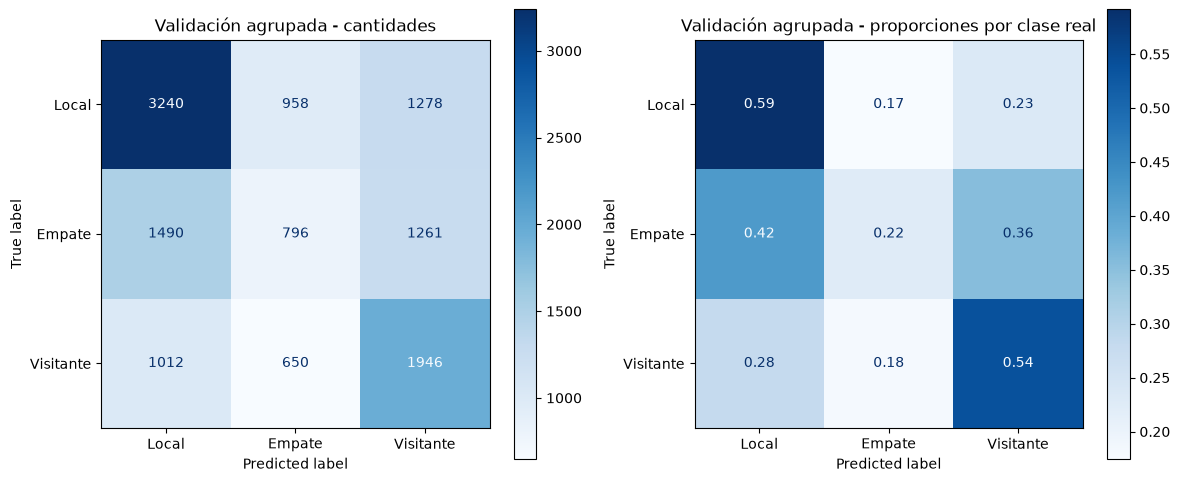

Metricas del ganador seleccionado por F1 macro medio anual:
                   Media anual de validacion cruzada  Validacion agrupada (todos los partidos)
F1 macro                                     43.645%                                   44.202%
Accuracy                                     48.126%                                   47.360%
Balanced accuracy                            45.673%                                   45.181%

Reporte por clase: validacion agrupada; no es una evaluacion de test.
              precision    recall  f1-score   support

       Local       0.56      0.59      0.58      5476
      Empate       0.33      0.22      0.27      3547
   Visitante       0.43      0.54      0.48      3608

    accuracy                           0.47     12631
   macro avg       0.44      0.45      0.44     12631
weighted avg       0.46      0.47      0.46     12631



In [8]:
from sklearn.base import clone
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
)
import matplotlib.pyplot as plt
import numpy as np


real_results = []
predicted_results = []

#volvemos a entrenar el mejor modelo para cada division temporal
for fit_indices, validation_indices in temporal_splits:

    fold_model = clone(
        random_search.best_estimator_
    )

    fold_model.fit(
        X_train.iloc[fit_indices],
        y_train.iloc[fit_indices],
    )

    fold_predictions = fold_model.predict(
        X_train.iloc[validation_indices]
    )

    real_results.extend(
        y_train.iloc[validation_indices]
    )

    predicted_results.extend(
        fold_predictions
    )


real_results = np.asarray(real_results)
predicted_results = np.asarray(predicted_results)

labels = ["L", "E", "V"]

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

#cantidad de partidos
ConfusionMatrixDisplay.from_predictions(
    real_results,
    predicted_results,
    labels=labels,
    display_labels=[
        "Local",
        "Empate",
        "Visitante",
    ],
    cmap="Blues",
    values_format="d",
    ax=axes[0],
)

axes[0].set_title(
    "Validación agrupada - cantidades"
)

#porcentaje correcto dentro de cada clase real
ConfusionMatrixDisplay.from_predictions(
    real_results,
    predicted_results,
    labels=labels,
    display_labels=[
        "Local",
        "Empate",
        "Visitante",
    ],
    normalize="true",
    cmap="Blues",
    values_format=".2f",
    ax=axes[1],
)

axes[1].set_title(
    "Validación agrupada - proporciones por clase real"
)

plt.tight_layout()
plt.show()


# Dos resumenes diferentes del mismo ganador y de los mismos folds.
# La media anual da igual peso a cada ano; el agrupado junta todos los partidos.
metrics_summary = pd.DataFrame(
    {
        "Media anual de validacion cruzada": {
            "F1 macro": random_search.cv_results_["mean_test_f1_macro"][random_search.best_index_],
            "Accuracy": random_search.cv_results_["mean_test_accuracy"][random_search.best_index_],
            "Balanced accuracy": random_search.cv_results_["mean_test_balanced_accuracy"][random_search.best_index_],
        },
        "Validacion agrupada (todos los partidos)": {
            "F1 macro": f1_score(real_results, predicted_results, average="macro", zero_division=0),
            "Accuracy": accuracy_score(real_results, predicted_results),
            "Balanced accuracy": balanced_accuracy_score(real_results, predicted_results),
        },
    }
)
print("Metricas del ganador seleccionado por F1 macro medio anual:")
print(metrics_summary.to_string(float_format=lambda value: f"{value:.3%}"))
print("\nReporte por clase: validacion agrupada; no es una evaluacion de test.")
print(
    classification_report(
        real_results,
        predicted_results,
        labels=labels,
        target_names=[
            "Local",
            "Empate",
            "Visitante",
        ],
        zero_division=0,
    )
)

In [9]:
# Registro persistente: ejecutar al terminar cada experimento.
import csv
import json
from datetime import datetime, timezone
from pathlib import Path
import load

# Guardamos junto al dataset, independientemente del directorio de ejecucion.
csv_path = Path(load.__file__).resolve().parent / "experimentos_bayes.csv"
best_index = random_search.best_index_
best_parameters = random_search.best_estimator_.get_params()
parameter_names = [
    "model__m",
    "model__fit_prior",
    "preprocessing__differences__discretizer__record_margin",
    "preprocessing__differences__discretizer__last_matches_margin",
    "preprocessing__differences__discretizer__goal_difference_margin",
    "preprocessing__differences__discretizer__attack_margin",
    "preprocessing__differences__discretizer__defense_margin",
    "preprocessing__differences__discretizer__elo_margin",
    "preprocessing__draw_rate__discretizer__low_threshold",
    "preprocessing__draw_rate__discretizer__high_threshold",
]
experiment = {
    "fecha_utc": datetime.now(timezone.utc).isoformat(),
    "origen": "ejecucion",
    "validation_years": json.dumps(validation_years),
    "window_years": window_years,
    "n_train": len(X_train),
    "n_test_reservado": len(test),
    "param_grid": json.dumps(param_grid, sort_keys=True),
    "mejores_parametros": json.dumps({
        name: best_parameters[name] for name in parameter_names
    }, sort_keys=True),
    "refit": random_search.refit,
    "cv_accuracy": random_search.cv_results_["mean_test_accuracy"][best_index],
    "cv_f1_macro": random_search.cv_results_["mean_test_f1_macro"][best_index],
    "cv_balanced_accuracy": random_search.cv_results_["mean_test_balanced_accuracy"][best_index],
    "reporte_validacion": classification_report(
        real_results, predicted_results, labels=labels,
        target_names=["Local", "Empate", "Visitante"], zero_division=0,
    ),
    "notas": f"Muestreo directo sin reemplazo; n_iter={candidate_count}; semilla={random_state}; cv_* son medias anuales; reporte_validacion es agrupado; test sin evaluar",
}
# Mantener una sola linea por experimento en el CSV.
experiment["reporte_validacion"] = " | ".join(
    " ".join(line.split())
    for line in experiment["reporte_validacion"].splitlines() if line.strip()
)
has_header = csv_path.exists() and csv_path.stat().st_size > 0
if has_header:
    with csv_path.open(newline="", encoding="utf-8") as file:
        if next(csv.reader(file)) != list(experiment):
            raise ValueError("El CSV tiene columnas incompatibles; no se modifico.")
with csv_path.open("a", newline="", encoding="utf-8") as file:
    writer = csv.DictWriter(file, fieldnames=experiment)
    if not has_header:
        writer.writeheader()
    writer.writerow(experiment)
print(f"Experimento guardado en {csv_path}")


Experimento guardado en D:\Repo Aprendizaje Automatico\AprendizajeAutomatico\Tarea1\dataset\experimentos_bayes.csv
